Connected to Python (pygpu-env) (Python 3.11.8)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
class DifferentiableCanvas(nn.Module):
    def __init__(self, canvas_size=128):
        super(DifferentiableCanvas, self).__init__()
        self.canvas_size = canvas_size

        # Create a coordinate grid of (X, Y) pixel positions
        y, x = torch.meshgrid(
            torch.linspace(0, 1, canvas_size, device=device),
            torch.linspace(0, 1, canvas_size, device=device),
            indexing="ij",
        )
        self.register_buffer("grid_x", x)
        self.register_buffer("grid_y", y)

    def draw_lines(self, stroke_params):
        """
        stroke_params: Tensor of shape (N, 5) -> [x1, y1, x2, y2, thickness]
        Returns a canvas of shape (canvas_size, canvas_size)
        """
        # Start with a clean white canvas (1.0 = white, 0.0 = black ink)
        canvas = torch.ones((self.canvas_size, self.canvas_size), device=device)

        # Use grid directly without unsqueeze
        gx = self.grid_x
        gy = self.grid_y

        for i in range(stroke_params.shape[0]):
            # Extract line parameters
            x1, y1, x2, y2, thickness = stroke_params[i]

            # Line segment vector AB
            ax, ay = x2 - x1, y2 - y1
            mag_sq = ax**2 + ay**2 + 1e-6

            # Projection factor t to find closest point on segment
            px, py = gx - x1, gy - y1
            t = (px * ax + py * ay) / mag_sq
            t = torch.clamp(t, 0.0, 1.0)

            # Closest point coordinates on the line segment
            closest_x = x1 + t * ax
            closest_y = y1 + t * ay

            # Distance from grid pixels to the closest point
            dist_sq = (gx - closest_x) ** 2 + (gy - closest_y) ** 2

            # Differentiable brush stroke intensity using Gaussian falloff
            # Soft clamping sigma to ensure smooth gradient flow
            sigma = torch.clamp(thickness, min=0.01, max=0.1)
            stroke = torch.exp(-dist_sq / (2 * sigma**2))

            # Apply ink to the canvas (subtracting from white background)
            canvas = canvas - stroke

        return torch.clamp(canvas, min=0.0, max=1.0)

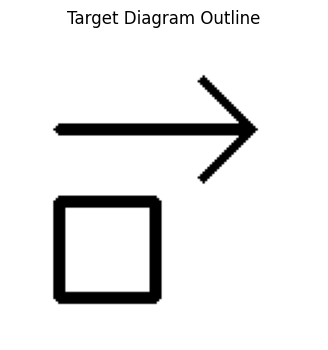

In [ ]:
# Target canvas dimensions
CANVAS_SIZE = 128

# Create an artificial target image (a clear outline structure)
target_img = np.ones((CANVAS_SIZE, CANVAS_SIZE), dtype=np.float32)

# Manually draw a structural target on a numpy array for testing
# We will make an arrow structure out of lines
import cv2

cv2.line(target_img, (20, 40), (100, 40), 0.0, 3)  # Main horizontal structural line
cv2.line(target_img, (100, 40), (80, 20), 0.0, 3)  # Arrow top arrowhead
cv2.line(target_img, (100, 40), (80, 60), 0.0, 3)  # Arrow bottom arrowhead
cv2.rectangle(
    target_img, (20, 70), (60, 110), 0.0, 3
)  # A structural diagram block below

# Convert target to a PyTorch tensor
target_tensor = torch.tensor(target_img, device=device)

# Visualize the target structure
plt.figure(figsize=(4, 4))
plt.title("Target Diagram Outline")
plt.imshow(target_tensor.cpu().numpy(), cmap="gray")
plt.axis("off")
plt.show()

In [ ]:
# Initialize the Differentiable Canvas
renderer = DifferentiableCanvas(canvas_size=CANVAS_SIZE)

# We want the model to solve this using exactly 5 strokes
NUM_STROKES = 5

# Initialize random stroke parameters: [x1, y1, x2, y2, thickness]
# We use sigmoid to naturally bound positions and thickness between 0.0 and 1.0
raw_stroke_params = torch.randn((NUM_STROKES, 5), device=device, requires_grad=True)

# Use Adam optimizer to adjust stroke parameters directly based on loss gradients
optimizer = optim.Adam([raw_stroke_params], lr=0.1)

# Training Loop
epochs = 500
losses = []

print("Beginning Line-by-Line Reinforcement & Optimization...")
for epoch in range(epochs + 1):
    optimizer.zero_grad()

    # Scale parameters safely into physical ranges via Sigmoid mapping
    scaled_params = torch.sigmoid(raw_stroke_params)
    # Scale coordinates to [0, 1] range, map thickness to a reasonable maximum pixel size
    coords = scaled_params[:, 0:4]
    thickness = scaled_params[:, 4:5] * 0.04 + 0.01
    current_strokes = torch.cat([coords, thickness], dim=1)

    # Render current strokes onto the canvas
    rendered_canvas = renderer.draw_lines(current_strokes)

    # Calculate error penalty (Mean Squared Error against Target Outline)
    loss = nn.MSELoss()(rendered_canvas, target_tensor)

    # Backpropagate error penalty to compute parameter adjustments
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if epoch % 100 == 0:
        print(f"Epoch {epoch:4d} | Structural Error Penalty: {loss.item():.5f}")

Beginning Line-by-Line Reinforcement & Optimization...
Epoch    0 | Structural Error Penalty: 0.16789
Epoch  100 | Structural Error Penalty: 0.04524
Epoch  200 | Structural Error Penalty: 0.04369
Epoch  300 | Structural Error Penalty: 0.04363
Epoch  400 | Structural Error Penalty: 0.04363
Epoch  500 | Structural Error Penalty: 0.04358


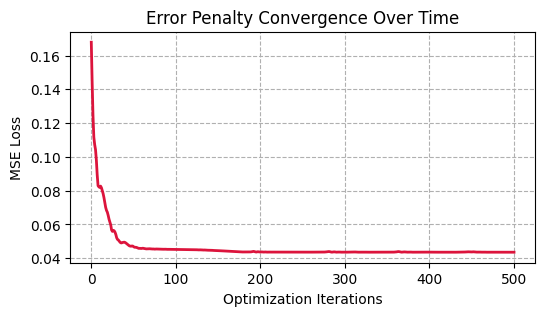

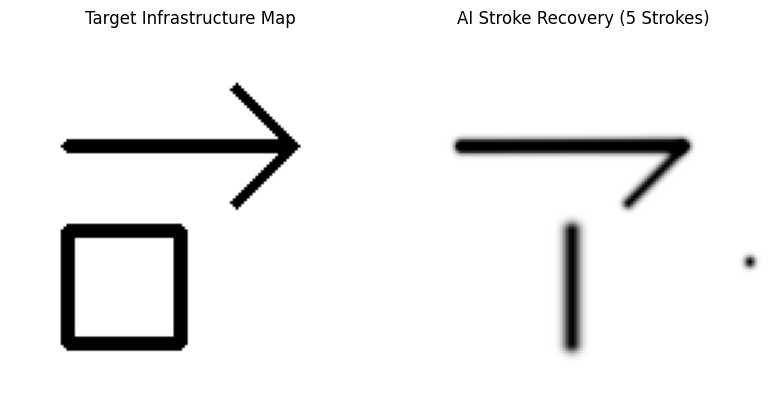

In [ ]:
# Plot the optimization loss history
plt.figure(figsize=(6, 3))
plt.plot(losses, color="crimson", lw=2)
plt.title("Error Penalty Convergence Over Time")
plt.xlabel("Optimization Iterations")
plt.ylabel("MSE Loss")
plt.grid(True, linestyle="--")
plt.show()

# Generate final output
with torch.no_grad():
    final_params = torch.sigmoid(raw_stroke_params)
    final_coords = final_params[:, 0:4]
    final_thick = final_params[:, 4:5] * 0.04 + 0.01
    optimized_strokes = torch.cat([final_coords, final_thick], dim=1)
    final_canvas = renderer.draw_lines(optimized_strokes).cpu().numpy()

# Compare Target vs AI Generation
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(target_tensor.cpu().numpy(), cmap="gray")
axes[0].set_title("Target Infrastructure Map")
axes[0].axis("off")

axes[1].imshow(final_canvas, cmap="gray")
axes[1].set_title(f"AI Stroke Recovery ({NUM_STROKES} Strokes)")
axes[1].axis("off")

plt.tight_layout()
plt.show()